### Time Series

This notebook is used for a time series analysis of the dataset. Here, I looked into launches over time, trends based on time, future/current launches, and created a prediction for future launches based on past data.

In [1]:
# Import

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/space_devs_launches_cleaned.csv')

# Datetime didn't save to csv file for whatever reason
df['launch_datetime'] = pd.to_datetime(df['launch_datetime'], errors='coerce')
df['launch_window_start'] = pd.to_datetime(df['launch_window_start'], errors='coerce')
df['launch_window_end'] = pd.to_datetime(df['launch_window_end'], errors='coerce')

In [2]:
# Separating current and future launches

planned_launches = df[
    df['status'].isin(["To Be Confirmed", "To Be Determined", "Go for Launch"])
].copy()

df = df[
    ~df['status'].isin(["To Be Confirmed", "To Be Determined", "Go for Launch"])
].copy()

In [3]:
# There is an unbalanced proportion of launches scheduled in December
# Doesn't seem likely that December is the best month for launches, more likely that December is used as a placeholder
# Scheduled launches are planned for sometime in 2026, but they don't know the exact month/day yet and may use December as a placeholder

planned_launches.groupby('month').size().sort_values()

planned_launches[planned_launches['month'] == 12].groupby('launch_datetime').size()

launch_datetime
2026-12-31 00:00:00+00:00    109
dtype: int64

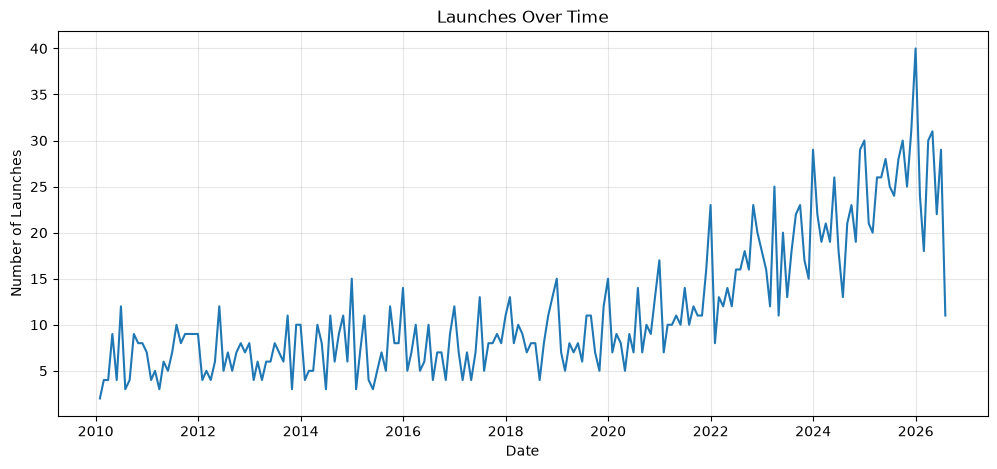

In [4]:
# Looking at launches over time

launches_by_month = (
    df.set_index('launch_datetime')
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(launches_by_month.index, launches_by_month.values)
plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

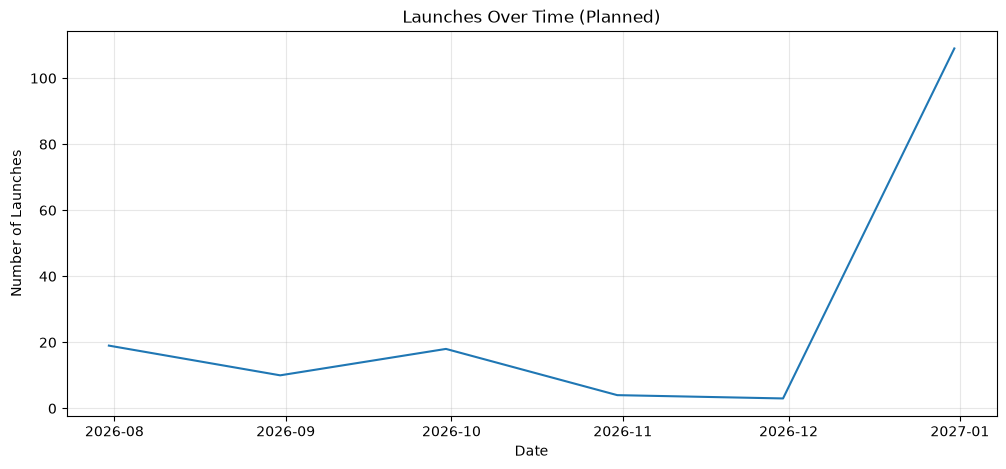

In [5]:
# Look at planned launches

planned_launches_by_month = (
    planned_launches.set_index('launch_datetime')
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(planned_launches_by_month.index, planned_launches_by_month.values)
plt.title("Launches Over Time (Planned)")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

# Seems to be a lot scheduled in December for some reason

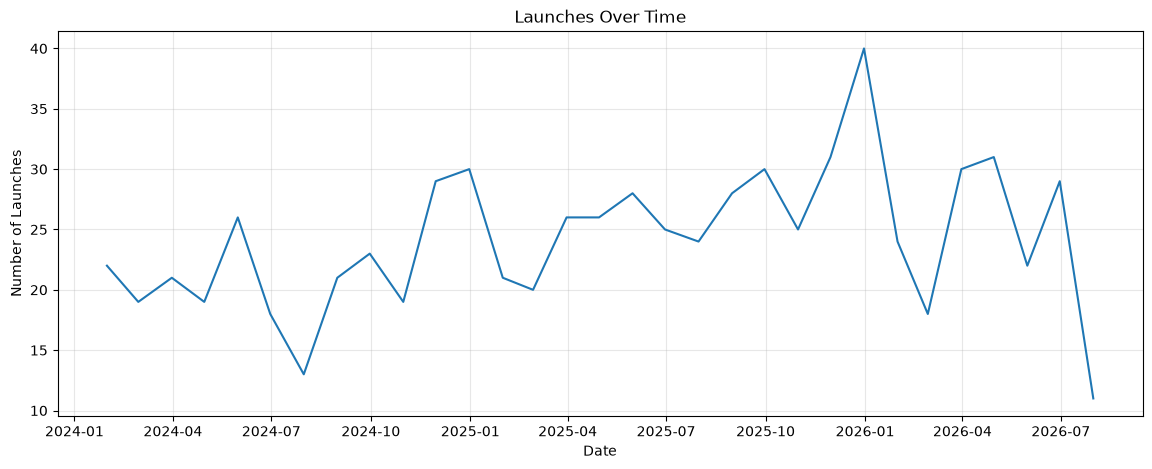

In [6]:
# Closer look at the last three years

last3_yrs_launches_by_month = launches_by_month.loc['2024-01-01':]

plt.figure(figsize=(14, 5))
plt.plot(last3_yrs_launches_by_month.index, last3_yrs_launches_by_month.values)
plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

# The 2027 spike is interesting? Something to look into later

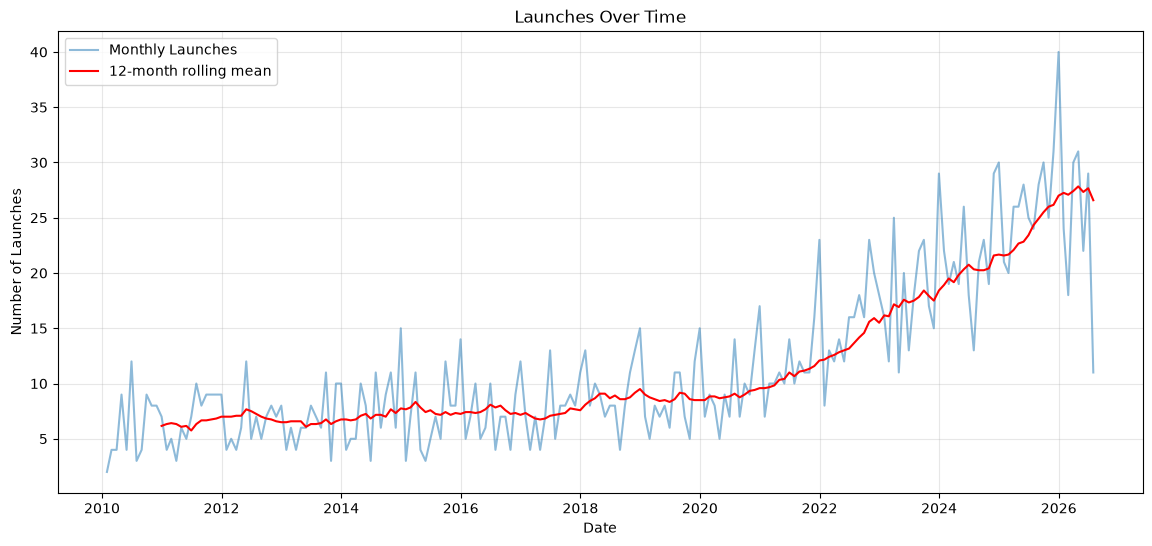

In [7]:
# Rolling Mean

rolling_mean = launches_by_month.rolling(window=12).mean()

plt.figure(figsize=(14, 6))

plt.plot(launches_by_month.index, launches_by_month.values, alpha=0.5, label="Monthly Launches")
plt.plot(rolling_mean.index, rolling_mean.values, linewidth=1.5, color='red', label='12-month rolling mean')

plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Overall trend of increasing number of launches over time, especially in the past 6 years

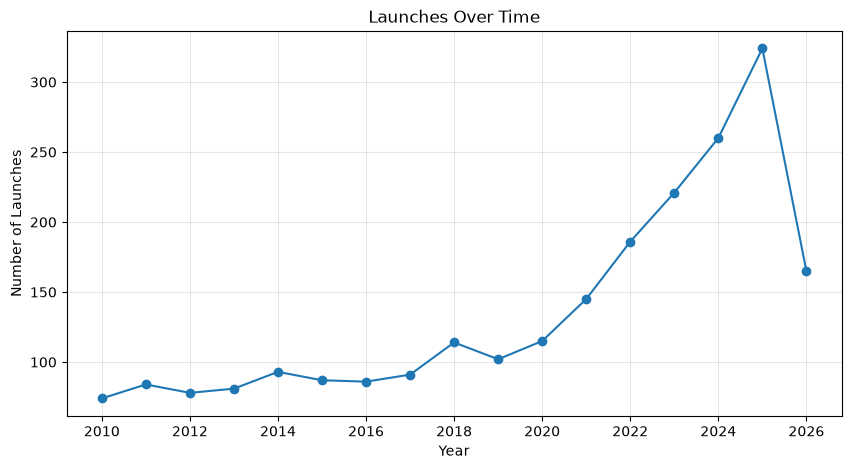

In [8]:
# Launches over time by year

launches_by_year = df.groupby('year').size()

plt.figure(figsize=(10, 5))
plt.plot(launches_by_year.index, launches_by_year.values, marker="o")
plt.title("Launches Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

# This does not include about 100 launches scheduled for the remainder of 2026

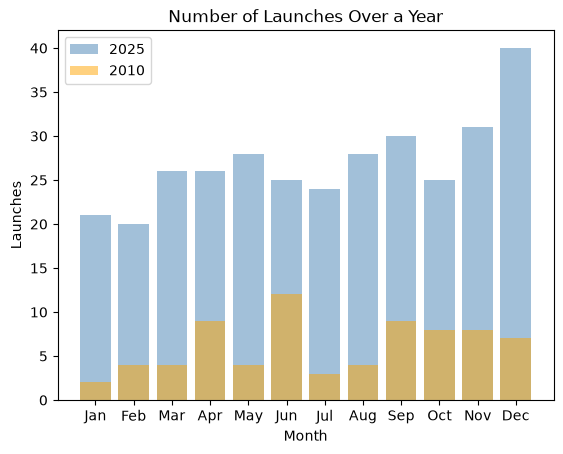

In [9]:
# Launches in the year 2010 vs. 2025

launches_by_month.index = pd.to_datetime(launches_by_month.index)

launches_2010 = launches_by_month[launches_by_month.index.year == 2010]
launches_2025 = launches_by_month[launches_by_month.index.year == 2025]

months = launches_2010.index.strftime('%b')

fig, ax = plt.subplots()

ax.bar(months, launches_2025, color='steelblue', alpha=0.5, label='2025')
ax.bar(months, launches_2010, color='orange', alpha=0.5, label='2010')


ax.set_xlabel('Month')
ax.set_ylabel('Launches')
ax.set_title('Number of Launches Over a Year')
ax.legend()

plt.show()

# Seems to be no clear seasonality for launches in a year

In [10]:
# Reformat the data for Prophet

df_prophet = launches_by_month.reset_index()
df_prophet.columns = ['ds', 'y']

# Removing timezone
df_prophet['ds'] = pd.to_datetime(df_prophet['ds']).dt.tz_localize(None)

df_prophet

,ds,y
0,2010-01-31,2
1,2010-02-28,4
2,2010-03-31,4
3,2010-04-30,9
4,2010-05-31,4
...,...,...
194,2026-03-31,30
195,2026-04-30,31
196,2026-05-31,22
197,2026-06-30,29


11:21:25 - cmdstanpy - INFO - Chain [1] start processing
11:21:28 - cmdstanpy - INFO - Chain [1] done processing


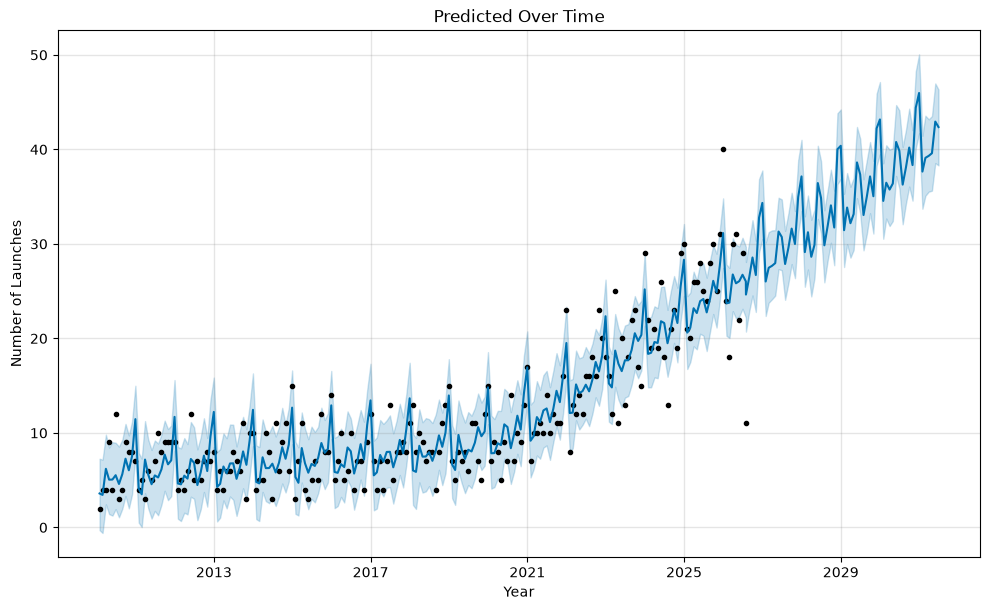

In [11]:
from prophet import Prophet 

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=60, freq="MS")
forecast = model.predict(future)

fig = model.plot(forecast)
plt.ylabel('Number of Launches')
plt.xlabel('Year')
plt.title('Predicted Over Time')
plt.show()

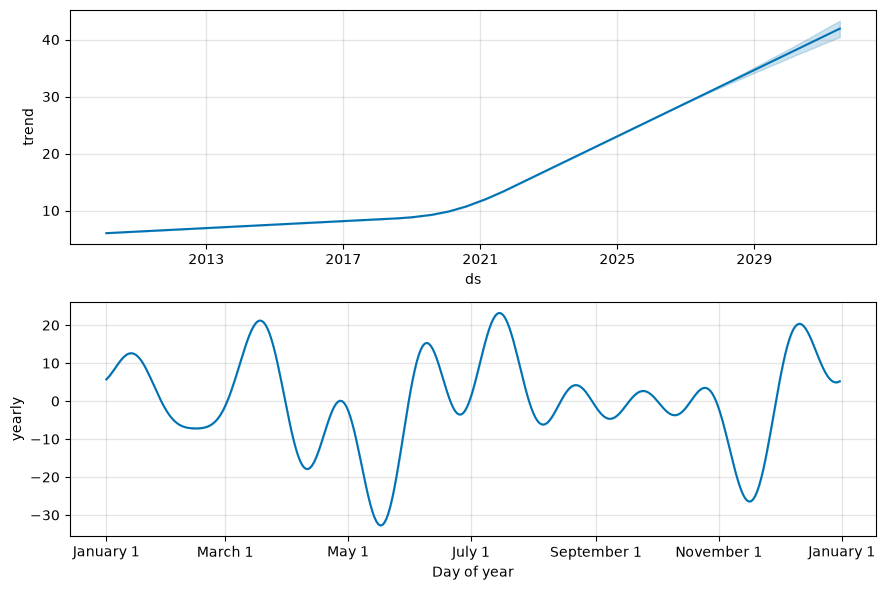

In [12]:
# Plot Components

fig = model.plot_components(forecast)

plt.show()

# Seems to be a spike of launches from 2020 onward